# ES Futures Roll Analysis — Signal Analysis: ESZ4/ESH5 Dec 2024

Comprehensive alpha exploration of the **second roll window** using tick-level mbp-10 data.  
Window 1 (ESU4→ESZ4, Sep 2024) is in `02_signal_analysis.ipynb`.

**Signals investigated:**
1. Fair value deviation — observed calendar spread vs cost-of-carry model
2. Lead-lag dynamics — does near-month price discovery lead deferred?
3. Order book imbalance (OBI) — does front-month book pressure predict back-month returns?
4. Trade flow imbalance — directional flow signal across the spread
5. FOMC event study — Dec 18 rate cut (25bp, "hawkish cut") effect on fair value and spread

**Data:** ESZ4 (front) / ESH5 (back), Dec 12–19 2024  
**Tick-level analysis day:** Dec 16 (crossover Monday — highest roll activity, 62.7% back-share)

In [16]:
import glob
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

DATA_DIR = Path('/Volumes/SEAGATE/Databento_Futures')
FRONT, BACK = 'ESZ4', 'ESH5'
ROLL_START  = '2024-12-12'
ROLL_END    = '2024-12-19'

# FOMC announcement: 25bp cut, Dec 18 2024 at 14:00 EST = 19:00 UTC
FOMC_UTC = pd.Timestamp('2024-12-18 19:00:00', tz='UTC')

# Dec is EST (UTC−5): 08:30–15:15 ET = 13:30–20:15 UTC
# (Sep window used 12:30–19:15 UTC because EDT is UTC−4)
RTH_OPEN  = datetime.strptime('13:30', '%H:%M').time()
RTH_CLOSE = datetime.strptime('20:15', '%H:%M').time()

## 1. Contract Specifications

In [17]:
defn = pd.read_parquet(DATA_DIR / f'definitions_{FRONT}_{BACK}.parquet')
specs = defn[['symbol', 'expiration', 'min_price_increment',
              'unit_of_measure_qty', 'currency']].copy()
specs.index = specs['symbol']
specs = specs.drop(columns='symbol')
display(specs)

exp_front = defn.loc[defn['symbol'] == FRONT, 'expiration'].iloc[0]
exp_back  = defn.loc[defn['symbol'] == BACK,  'expiration'].iloc[0]
tick_size = defn['min_price_increment'].iloc[0]       # 0.25 index points
multiplier = defn['unit_of_measure_qty'].iloc[0]      # $50 per index point
tick_value = tick_size * multiplier                   # $12.50 per tick

dt_years = (exp_back - exp_front).total_seconds() / (365.25 * 24 * 3600)

print(f'\nFront expiry : {exp_front}')
print(f'Back  expiry : {exp_back}')
print(f'ΔT           : {dt_years:.6f} years  ({dt_years*365.25:.1f} calendar days)')
print(f'Tick size    : {tick_size} pts  →  ${tick_value:.2f} per contract')

,expiration,min_price_increment,unit_of_measure_qty,currency
symbol,,,,
ESH5,2025-03-21 13:30:00+00:00,0.2500,50.0000,USD
ESZ4,2024-12-20 14:30:00+00:00,0.2500,50.0000,USD



Front expiry : 2024-12-20 14:30:00+00:00
Back  expiry : 2025-03-21 13:30:00+00:00
ΔT           : 0.249030 years  (91.0 calendar days)
Tick size    : 0.25 pts  →  $12.50 per contract


## 2. Daily Context — Settlement Prices & Open Interest

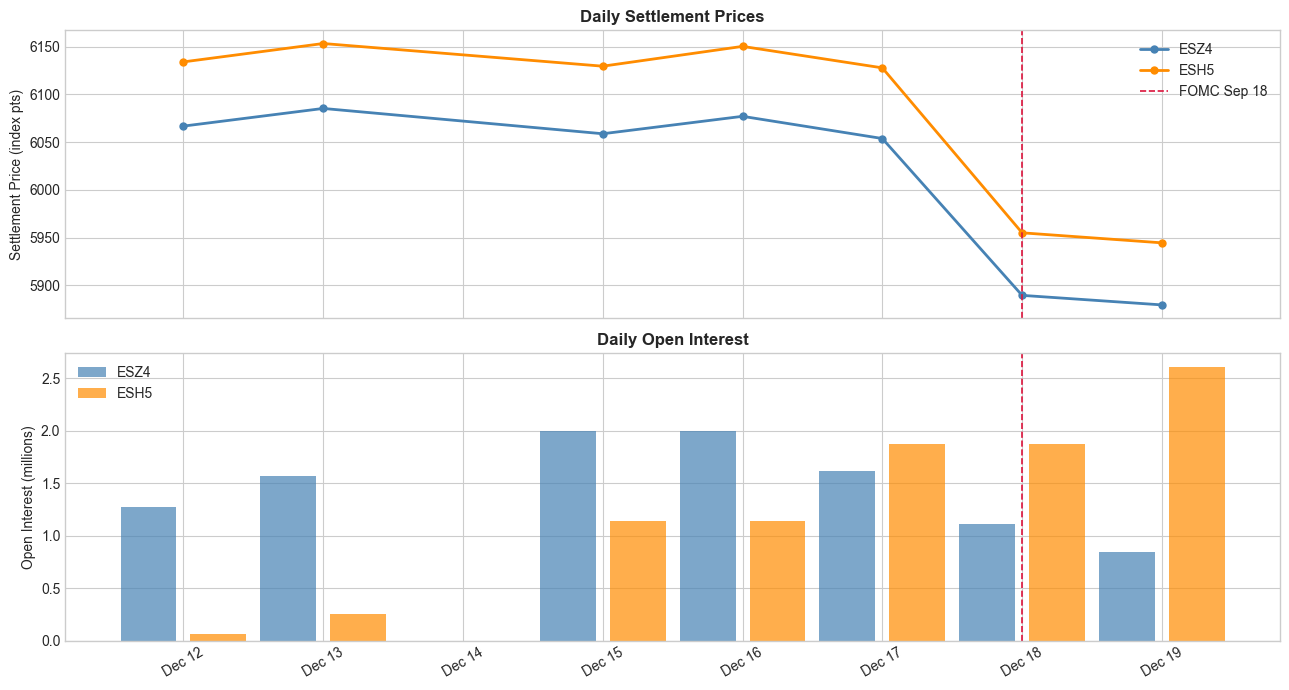


OI Ratio (back / total):


,oi_ratio
date,
2024-12-12 00:00:00+00:00,0.0521
2024-12-13 00:00:00+00:00,0.1421
2024-12-15 00:00:00+00:00,0.3633
2024-12-16 00:00:00+00:00,0.3633
2024-12-17 00:00:00+00:00,0.5373
2024-12-18 00:00:00+00:00,0.6274
2024-12-19 00:00:00+00:00,0.7545


In [18]:
stats = pd.read_parquet(DATA_DIR / f'stats_{FRONT}_{BACK}_{ROLL_START}.parquet')
stats['date'] = stats.index.normalize()

# stat_type=6 → open interest (quantity field); stat_type=5 → settlement price
oi   = (stats[stats['stat_type'] == 6]
        .groupby(['date', 'symbol'])['quantity'].last()
        .unstack('symbol'))
settl = (stats[stats['stat_type'] == 5]
         .groupby(['date', 'symbol'])['price'].last()
         .unstack('symbol'))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Settlement prices
ax = axes[0]
for sym, col in [(FRONT, 'steelblue'), (BACK, 'darkorange')]:
    if sym in settl.columns:
        ax.plot(settl.index, settl[sym], color=col, marker='o',
                linewidth=2, markersize=5, label=sym)
ax.axvline(FOMC_UTC.normalize(), color='crimson', linestyle='--',
           linewidth=1.2, label='FOMC Sep 18')
ax.set_ylabel('Settlement Price (index pts)')
ax.set_title('Daily Settlement Prices', fontweight='bold')
ax.legend()

# Open interest
ax = axes[1]
oi_ratio = oi[BACK] / (oi[FRONT] + oi[BACK]) if FRONT in oi and BACK in oi else None
for sym, col in [(FRONT, 'steelblue'), (BACK, 'darkorange')]:
    if sym in oi.columns:
        ax.bar([d + pd.Timedelta(hours=-6 if sym==FRONT else 6) for d in oi.index],
               oi[sym] / 1e6, width=0.4, color=col, alpha=0.7, label=sym)
ax.axvline(FOMC_UTC.normalize(), color='crimson', linestyle='--', linewidth=1.2)
ax.set_ylabel('Open Interest (millions)')
ax.set_title('Daily Open Interest', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)

fig.tight_layout()
plt.show()

if oi_ratio is not None:
    print('\nOI Ratio (back / total):')
    display(oi_ratio.rename('oi_ratio').to_frame())

## 3. Full-Window Calendar Spread (1-second sampling)

Load all 7 trading days — **top-of-book columns only** to keep memory manageable.
Resample to 1-second midprice bars; LVCF-align front and back.

In [19]:
MBP_COLS_CORE = ['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00', 'symbol']

def load_day_1s(filepath: str) -> pd.DataFrame:
    """Load one day of mbp-10, compute midprice, resample to 1-second last-value."""
    df = pd.read_parquet(filepath, columns=MBP_COLS_CORE)
    df['mid'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    df['spread_1'] = df['ask_px_00'] - df['bid_px_00']   # bid-ask spread
    return (
        df.groupby('symbol')[['mid', 'spread_1']]
        .resample('1s')
        .last()
        .ffill()
    )

files = sorted(glob.glob(str(DATA_DIR / f'mbp10_{FRONT}_{BACK}_{ROLL_START}_*.parquet')))
print(f'Loading {len(files)} day files...')
day_frames = []
for f in files:
    day = Path(f).stem.split('_')[-1]
    print(f'  {day}', end=' ', flush=True)
    day_frames.append(load_day_1s(f))
print('done.')

full = pd.concat(day_frames).sort_index()
print(f'\nFull window shape: {full.shape}')
display(full.head(4))

Loading 7 day files...
  2024-12-12   2024-12-13   2024-12-15   2024-12-16   2024-12-17   2024-12-18   2024-12-19 done.

Full window shape: (1101593, 2)


mid  spread_1
symbol ts_recv                                      
ESH5   2024-12-12 00:00:00+00:00 6153.0000    0.5000
       2024-12-12 00:00:01+00:00 6153.1250    0.2500
       2024-12-12 00:00:02+00:00 6153.0000    0.5000
       2024-12-12 00:00:03+00:00 6153.0000    0.5000

In [20]:
# Pivot to wide: one column per (metric, symbol)
wide = full.unstack(level='symbol')

# Calendar spread (full Globex, no RTH filter)
# 12:30–19:15 UTC ≈ 8:30 AM–3:15 PM EDT (CME RTH). We keep full Globex here
# so sessions run end-to-end with day markers instead of whitespace gaps.
rth = wide.copy()
rth['spread'] = rth[('mid', BACK)] - rth[('mid', FRONT)]

print('Records:', len(rth))
print('Spread stats (index pts):')
display(rth['spread'].describe())

# ── Session-continuous x-axis helpers ─────────────────────────────────────
_rth_x    = np.arange(len(rth))
_rth_dates = pd.Series(rth.index.date, index=range(len(rth)))
_day_bounds = _rth_dates[_rth_dates != _rth_dates.shift()].index[1:].tolist()
_day_tick_pos = [0] + _day_bounds
_day_tick_lbl = [
    pd.Timestamp(str(rth.index[i].date())).strftime('%a\n%b %d')
    for i in _day_tick_pos
]

def _xpos(ts):
    """UTC timestamp → nearest session-continuous integer position."""
    return min(int(rth.index.searchsorted(ts)), len(rth) - 1)

FOMC_X = _xpos(FOMC_UTC)

def apply_day_axis(axes_list):
    """Apply session-continuous x-axis with day-boundary markers to a list of axes."""
    for ax in axes_list:
        for b in _day_bounds:
            ax.axvline(b, color='#aaaaaa', lw=0.8, linestyle=':', alpha=0.8, zorder=0)
        ax.set_xticks(_day_tick_pos)
        ax.set_xticklabels(_day_tick_lbl, fontsize=9)
        ax.xaxis.set_minor_locator(plt.NullLocator())


Records: 550797
Spread stats (index pts):


count   550796.0000
mean        69.9837
std          3.0246
min         57.2500
25%         67.2500
50%         70.2500
75%         73.2500
max         78.3750
Name: spread, dtype: float64

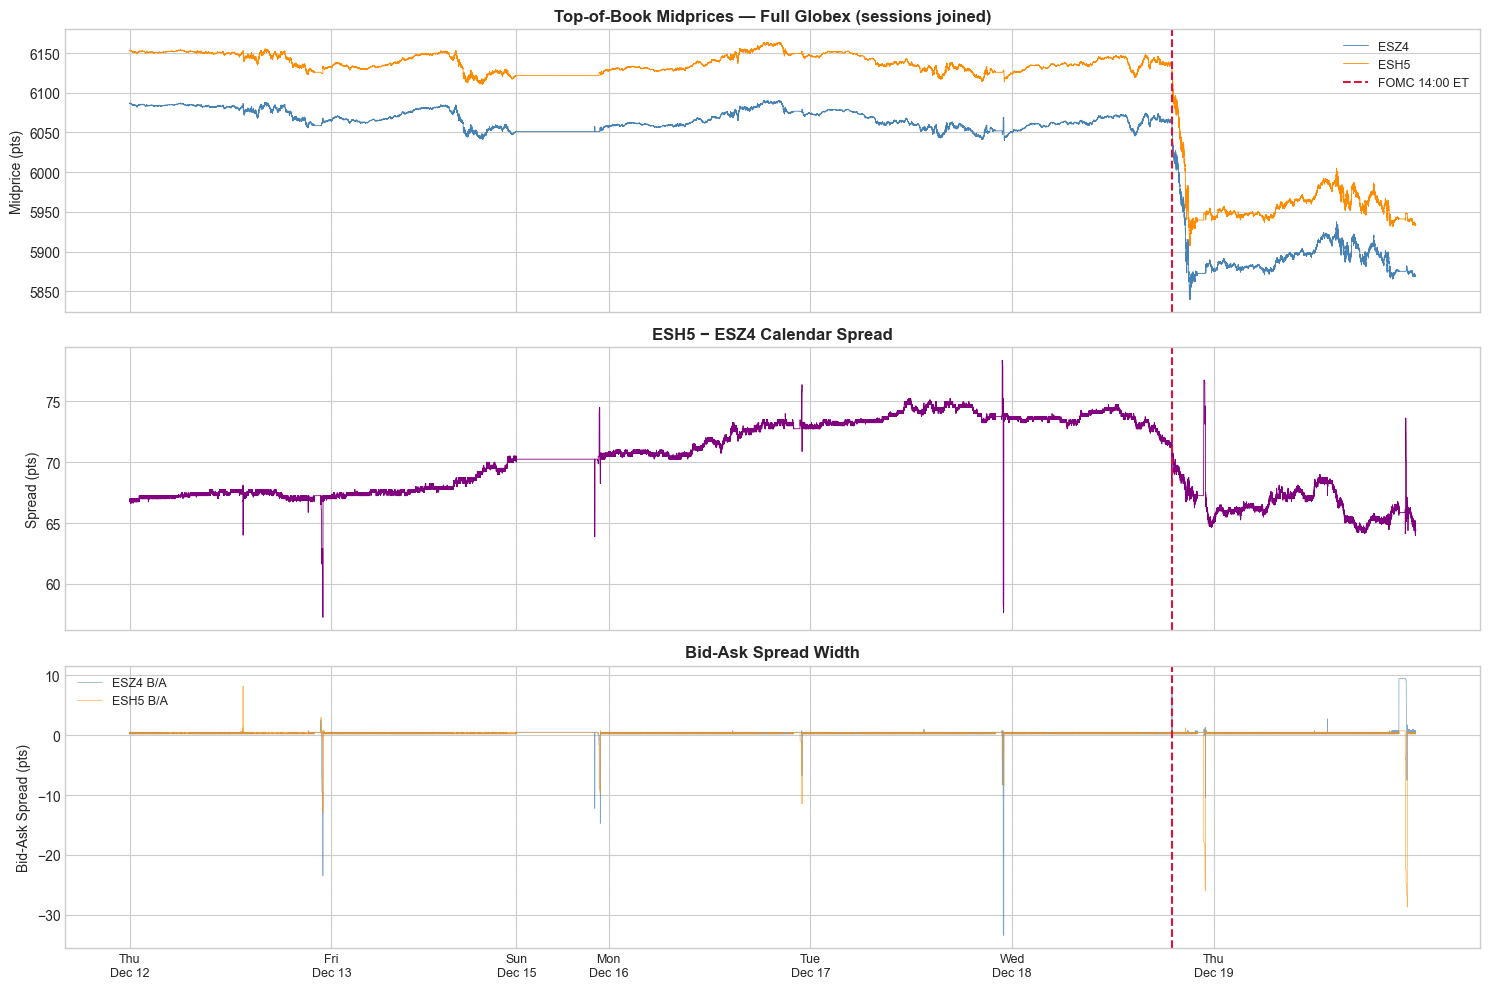

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

ax = axes[0]
ax.plot(_rth_x, rth[('mid', FRONT)], color='steelblue',  lw=0.6, label=FRONT)
ax.plot(_rth_x, rth[('mid', BACK)],  color='darkorange', lw=0.6, label=BACK)
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle='--', label='FOMC 14:00 ET')
ax.set_ylabel('Midprice (pts)')
ax.set_title('Top-of-Book Midprices — Full Globex (sessions joined)', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(_rth_x, rth['spread'], color='purple', lw=0.6)
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle='--')
ax.set_ylabel('Spread (pts)')
ax.set_title(f'{BACK} − {FRONT} Calendar Spread', fontweight='bold')

ax = axes[2]
ax.plot(_rth_x, rth[('spread_1', FRONT)], color='steelblue',  lw=0.5, alpha=0.7, label=f'{FRONT} B/A')
ax.plot(_rth_x, rth[('spread_1', BACK)],  color='darkorange', lw=0.5, alpha=0.7, label=f'{BACK} B/A')
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle='--')
ax.set_ylabel('Bid-Ask Spread (pts)')
ax.set_title('Bid-Ask Spread Width', fontweight='bold')
ax.legend(fontsize=9)

apply_day_axis(axes)
fig.tight_layout()
plt.show()


## 4. Fair Value Model & Spread Deviation

$$FV_t = S_t \cdot (r_f - q) \cdot \Delta T$$

- $S_t$ ≈ front-month midprice (proxy for SPX spot; T_front ≤ 8 days so carry adjustment < 0.1%)
- $r_f$: SOFR ~4.62% → **step down to ~4.37% at FOMC announcement (Dec 18 14:00 ET, 25bp cut)**
- $q$: S&P 500 trailing dividend yield ≈ 1.30%
- $\Delta T$: exact time between expiries (from `definition` schema)

In [22]:
DIV_YIELD    = 0.0130
# FOMC config: (announcement UTC, cut in decimal — positive = cut, negative = hike)
# Known from Fed statement at announcement time; not look-ahead.
FOMC_CUT_BPS = 0.0025   # 25bp cut announced at FOMC_UTC

# ── Load daily SOFR from local CSV ────────────────────────────────────────────
_sofr_file = DATA_DIR / 'SOFR.csv'
_sofr_raw  = pd.read_csv(
    _sofr_file,
    parse_dates=['observation_date'],
    index_col='observation_date',
)
_sofr_raw.columns = ['sofr_pct']
_sofr_raw['sofr'] = pd.to_numeric(_sofr_raw['sofr_pct'], errors='coerce') / 100
_sofr_raw = _sofr_raw['sofr'].dropna()

print('Daily SOFR in roll window:')
_window_mask = (_sofr_raw.index >= ROLL_START) & (_sofr_raw.index <= ROLL_END)
for d, v in _sofr_raw[_window_mask].items():
    print(f'  {d.date()}  {v*100:.4f}%')

_sofr_lookup = pd.Series(
    _sofr_raw.values,
    index=pd.DatetimeIndex(_sofr_raw.index).tz_localize('UTC'),
)
_daily_idx = pd.date_range(rth.index[0].normalize(), rth.index[-1].normalize(),
                           freq='D', tz='UTC')
_sofr_daily = _sofr_lookup.reindex(_daily_idx).ffill().bfill()

r_f = _sofr_daily.reindex(rth.index.normalize()).values
r_f = pd.Series(r_f, index=rth.index, dtype=float)

# ── FOMC intraday override (no look-ahead) ────────────────────────────────────
# We do NOT use the Dec-19 SOFR publication (that would be look-ahead for Dec-18 bars).
_pre_fomc_sofr  = float(r_f[r_f.index < FOMC_UTC].iloc[-1])
_post_fomc_sofr = _pre_fomc_sofr - FOMC_CUT_BPS
r_f = r_f.copy()
r_f[r_f.index >= FOMC_UTC] = _post_fomc_sofr

SOFR_PRE  = _pre_fomc_sofr
SOFR_POST = _post_fomc_sofr

print(f'\nPre-FOMC  SOFR (last published): {_pre_fomc_sofr*100:.4f}%')
print(f'Post-FOMC SOFR (announced cut)  : {_post_fomc_sofr*100:.4f}%')
print(f'(Dec-19 published SOFR for reference: '
      f'{_sofr_raw[_sofr_raw.index.date == pd.Timestamp(ROLL_END).date()].iloc[0]*100:.4f}%)')

# ── FV and deviation ──────────────────────────────────────────────────────────
carry = r_f - DIV_YIELD
fv    = rth[('mid', FRONT)] * carry * dt_years
dev   = rth['spread'] - fv

Z_WINDOWS = [('30s', '30s'), ('1min', '1m'), ('2min', '2m'), ('5min', '5m'), ('10min', '10m')]
Z_COLORS  = {'30s': '#e74c3c', '1m': '#e67e22', '2m': '#f1c40f',
             '5m': '#27ae60',  '10m': '#2980b9'}

dev_z_all = {}
for win_str, win_label in Z_WINDOWS:
    mu  = dev.rolling(win_str).mean()
    std = dev.rolling(win_str).std().replace(0, np.nan)
    dev_z_all[win_label] = (dev - mu) / std

dev_z = dev_z_all['1m']

print('\nDeviation (spread − FV) summary (index pts):')
display(dev.describe())
print(f'\nFV range: {fv.min():.2f} – {fv.max():.2f}')
print(f'Expected FV step-down at FOMC: ~{rth[("mid", FRONT)].mean() * FOMC_CUT_BPS * dt_years:.2f} pts')

print('\nEntry frequency at |z| > 2σ:')
print(f'  {"Window":>5}   {"Long %":>7}   {"Short %":>8}   {"Total %":>8}')
for _, wl in Z_WINDOWS:
    z  = dev_z_all[wl]
    n  = len(z.dropna())
    nl = (z < -2).sum()
    ns = (z >  2).sum()
    print(f'  {wl:>5}   {nl/n*100:>6.2f}%   {ns/n*100:>7.2f}%   {(nl+ns)/n*100:>7.2f}%')

Daily SOFR in roll window:
  2024-12-12  4.6200%
  2024-12-13  4.6000%
  2024-12-16  4.6500%
  2024-12-17  4.6200%
  2024-12-18  4.5700%
  2024-12-19  4.3000%

Pre-FOMC  SOFR (last published): 4.5700%
Post-FOMC SOFR (announced cut)  : 4.3200%
(Dec-19 published SOFR for reference: 4.3000%)

Deviation (spread − FV) summary (index pts):


count   550796.0000
mean        21.0174
std          2.6985
min          7.0789
25%         18.0397
50%         21.1245
75%         23.3416
max         32.5865
dtype: float64


FV range: 43.92 – 50.81
Expected FV step-down at FOMC: ~3.76 pts

Entry frequency at |z| > 2σ:
  Window    Long %    Short %    Total %
    30s     3.64%      3.47%      7.11%
     1m     3.76%      3.54%      7.30%
     2m     3.88%      3.62%      7.51%
     5m     4.15%      4.08%      8.23%
    10m     4.49%      4.60%      9.09%


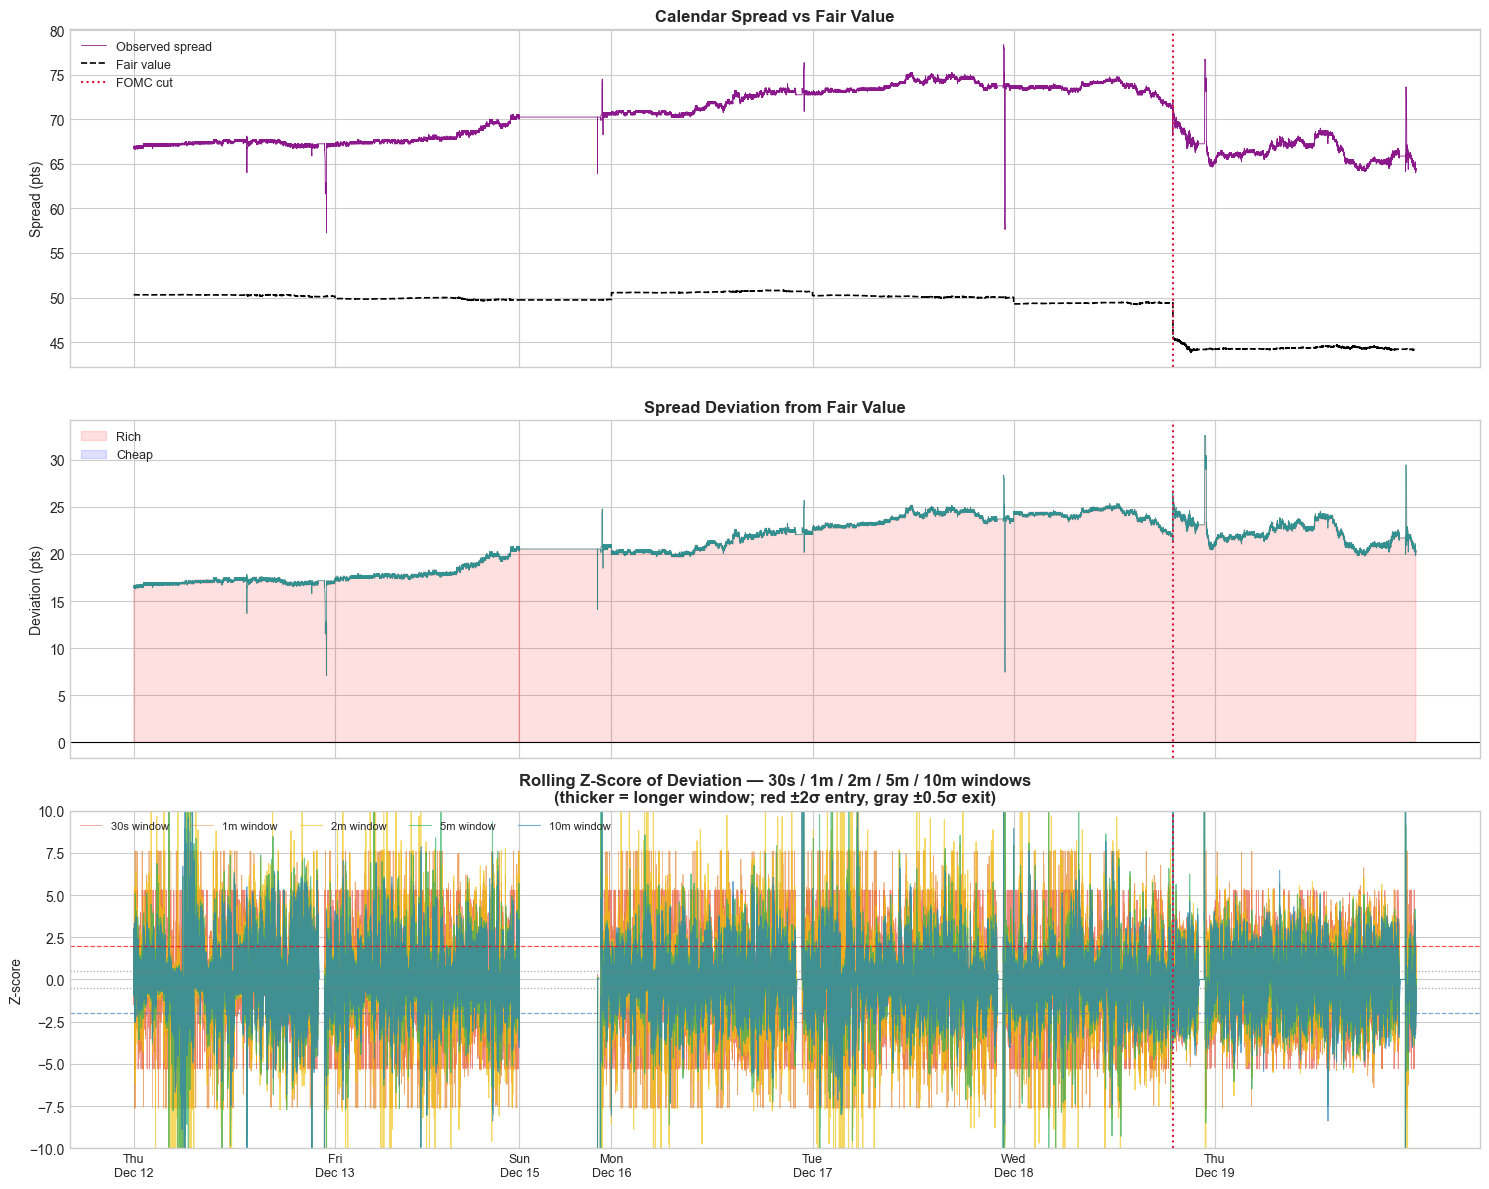

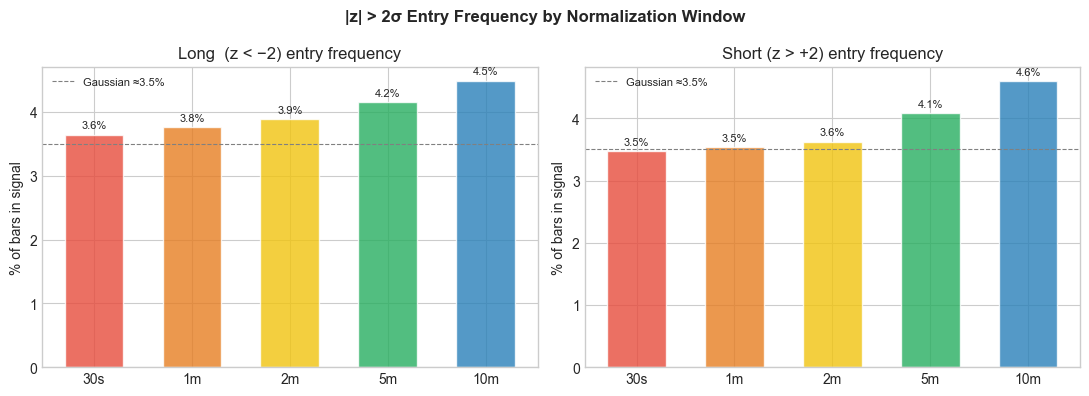

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Panel 1: Spread vs FV
ax = axes[0]
ax.plot(_rth_x, rth['spread'], color='purple', lw=0.6, alpha=0.9, label='Observed spread')
ax.plot(_rth_x, fv,            color='black',  lw=1.2, linestyle='--', label='Fair value')
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle=':', label='FOMC cut')
ax.set_ylabel('Spread (pts)')
ax.set_title('Calendar Spread vs Fair Value', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Raw deviation
ax = axes[1]
ax.plot(_rth_x, dev, color='teal', lw=0.5, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle=':')
ax.fill_between(_rth_x, dev, 0, where=(dev > 0), alpha=0.12, color='red',  label='Rich')
ax.fill_between(_rth_x, dev, 0, where=(dev < 0), alpha=0.12, color='blue', label='Cheap')
ax.set_ylabel('Deviation (pts)')
ax.set_title('Spread Deviation from Fair Value', fontweight='bold')
ax.legend(fontsize=9)

# Panel 3: All z-scores overlaid
ax = axes[2]
for _, wl in Z_WINDOWS:
    ax.plot(_rth_x, dev_z_all[wl], color=Z_COLORS[wl],
            lw=0.5 if wl in ('30s', '1m') else 0.8,
            alpha=0.65, label=f'{wl} window')
for lvl, col, ls in [(2, 'red', '--'), (-2, 'steelblue', '--'),
                     (0.5, 'gray', ':'), (-0.5, 'gray', ':')]:
    ax.axhline(lvl, color=col, lw=0.9, linestyle=ls, alpha=0.7)
ax.axvline(FOMC_X, color='crimson', lw=1.5, linestyle=':')
ax.set_ylim(-10, 10)
ax.set_ylabel('Z-score')
ax.set_title('Rolling Z-Score of Deviation — 30s / 1m / 2m / 5m / 10m windows\n'
             '(thicker = longer window; red ±2σ entry, gray ±0.5σ exit)',
             fontweight='bold')
ax.legend(fontsize=8, ncol=5, loc='upper left')

apply_day_axis(axes)
fig.tight_layout()
plt.show()

# ── Entry-frequency bar comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = [wl for _, wl in Z_WINDOWS]
long_pct  = [(dev_z_all[wl] < -2).sum() / len(dev_z_all[wl].dropna()) * 100 for wl in labels]
short_pct = [(dev_z_all[wl] >  2).sum() / len(dev_z_all[wl].dropna()) * 100 for wl in labels]
colors    = [Z_COLORS[wl] for wl in labels]

x = np.arange(len(labels))
w = 0.35
for ax, vals, side in [(axes[0], long_pct,  'Long  (z < −2)'),
                        (axes[1], short_pct, 'Short (z > +2)')]:
    ax.bar(x, vals, color=colors, alpha=0.8, edgecolor='white', width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('% of bars in signal'); ax.set_title(f'{side} entry frequency')
    ax.axhline(3.5, color='gray', lw=0.8, linestyle='--', label='Gaussian ≈3.5%')
    ax.legend(fontsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=8)

fig.suptitle('|z| > 2σ Entry Frequency by Normalization Window', fontweight='bold')
fig.tight_layout()
plt.show()


## 5. Lead-Lag Analysis (Tick Level — Dec 16)

Load the crossover-day file at full tick resolution.  
For each contract, extract midprice at every book update. Compute 1-second midprice returns.  
Cross-correlate front returns with back returns at lags −10s to +10s.

> **Hypothesis** (Guan et al. 2025): near-month leads deferred — positive correlation at lag > 0 means
> front today predicts back in the future.

In [24]:
DAY_FILE = str(DATA_DIR / f'mbp10_{FRONT}_{BACK}_{ROLL_START}_2024-12-16.parquet')

print('Loading Dec 16 tick data...', flush=True)
tick = pd.read_parquet(DAY_FILE, columns=MBP_COLS_CORE)
tick['mid'] = (tick['bid_px_00'] + tick['ask_px_00']) / 2
print(f'  {len(tick):,} records, {tick["symbol"].value_counts().to_dict()}')

# Split by symbol, keep RTH only — 13:30–20:15 UTC = 08:30–15:15 EST
t_front = tick[tick['symbol'] == FRONT].between_time('13:30', '20:15')
t_back  = tick[tick['symbol'] == BACK ].between_time('13:30', '20:15')

# 1-second midprice (last quote per second)
mid_f = t_front['mid'].resample('1s').last().ffill().rename('mid_front')
mid_b = t_back ['mid'].resample('1s').last().ffill().rename('mid_back')

# Align on common 1s grid
aligned = pd.concat([mid_f, mid_b], axis=1).dropna()

# Log returns
ret_f = np.log(aligned['mid_front']).diff().dropna()
ret_b = np.log(aligned['mid_back' ]).diff().dropna()
ret   = pd.concat([ret_f, ret_b], axis=1).dropna()

print(f'\nAligned 1s bars: {len(aligned)}  |  non-zero front returns: {(ret_f!=0).sum()}')

Loading Dec 16 tick data...
  12,152,767 records, {'ESH5': 7093810, 'ESZ4': 5058957}

Aligned 1s bars: 24300  |  non-zero front returns: 7800


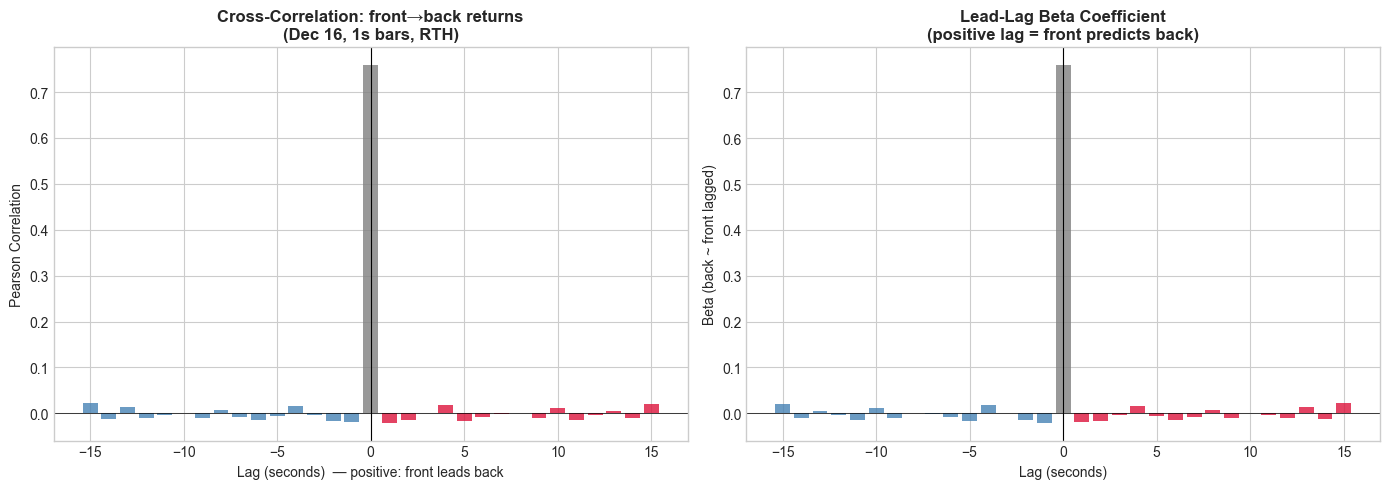

Peak cross-correlation: r=0.7593 at lag=0s


In [25]:
# Cross-correlation: front leads back at positive lag
max_lag = 15
lags    = range(-max_lag, max_lag + 1)
xcorr   = [ret['mid_front'].corr(ret['mid_back'].shift(lag)) for lag in lags]

from numpy.polynomial import polynomial as P
betas = []
for lag in lags:
    x = ret['mid_front'].shift(lag).dropna()
    y = ret['mid_back'].reindex(x.index).dropna()
    x = x.reindex(y.index)
    if len(x) > 10:
        beta = np.cov(x, y)[0, 1] / np.var(x) if np.var(x) > 0 else 0
    else:
        beta = 0
    betas.append(beta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['crimson' if l > 0 else ('steelblue' if l < 0 else 'gray') for l in lags]
ax.bar(lags, xcorr, color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Lag (seconds)  — positive: front leads back')
ax.set_ylabel('Pearson Correlation')
ax.set_title(f'Cross-Correlation: front→back returns\n(Dec 16, 1s bars, RTH)', fontweight='bold')

ax = axes[1]
ax.bar(lags, betas, color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Beta (back ~ front lagged)')
ax.set_title('Lead-Lag Beta Coefficient\n(positive lag = front predicts back)', fontweight='bold')

fig.tight_layout()
plt.show()

peak_lag  = lags[int(np.argmax(xcorr))]
peak_corr = max(xcorr)
print(f'Peak cross-correlation: r={peak_corr:.4f} at lag={peak_lag}s')

## 6. Order Book Imbalance (OBI)

**L1 OBI** = (bid_sz − ask_sz) / (bid_sz + ask_sz) ∈ [−1, +1]  
Positive → more size on bid → buy pressure.  

Key question: does **front-month OBI** predict back-month midprice changes?

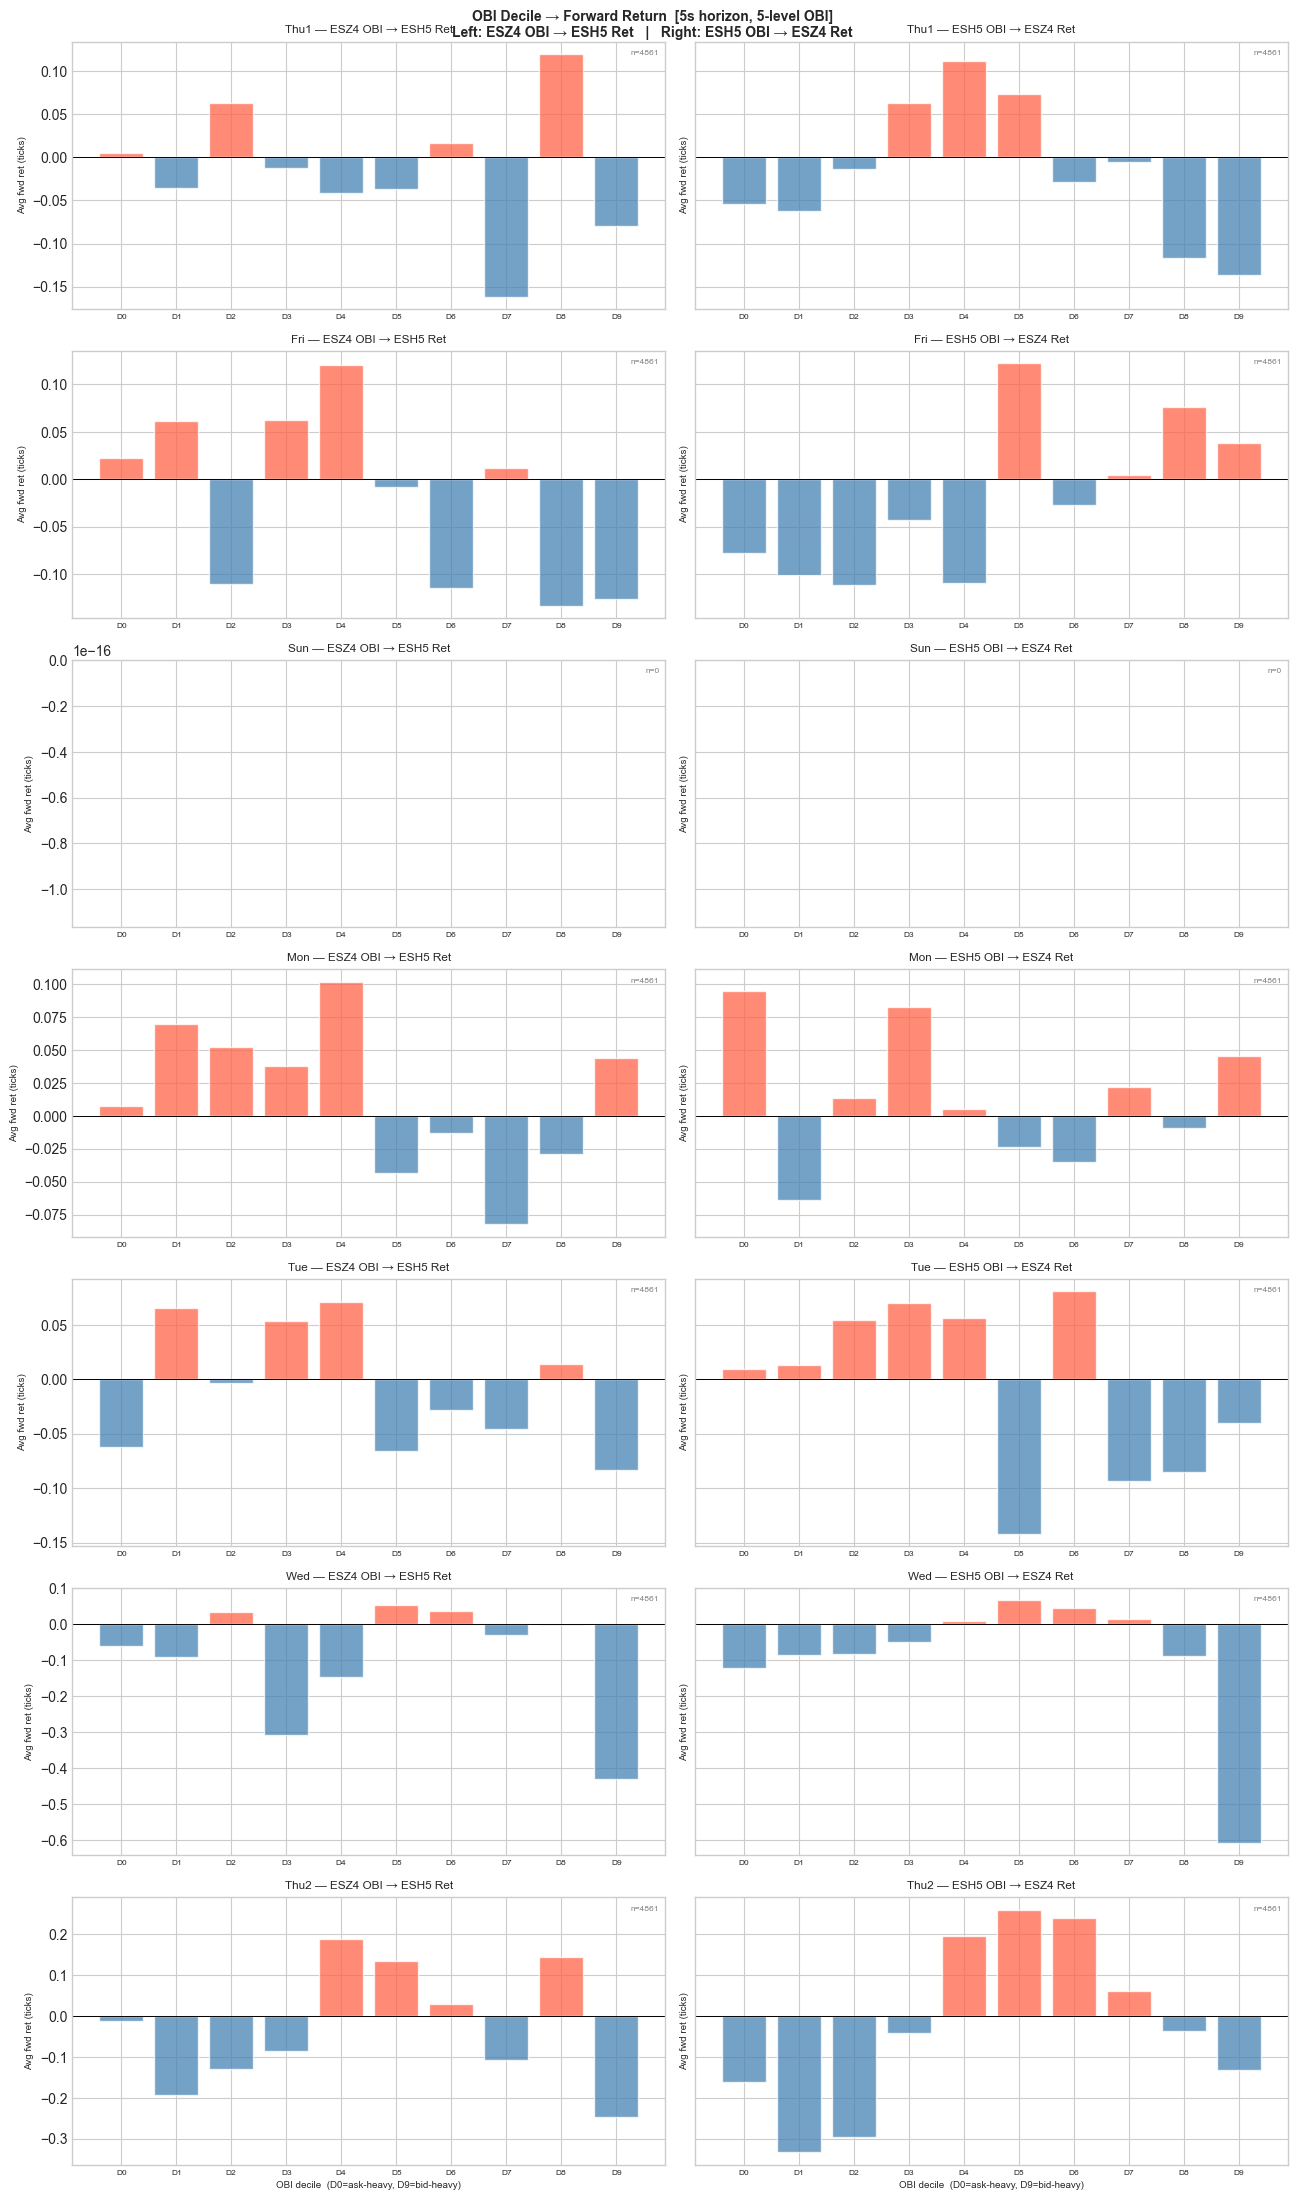

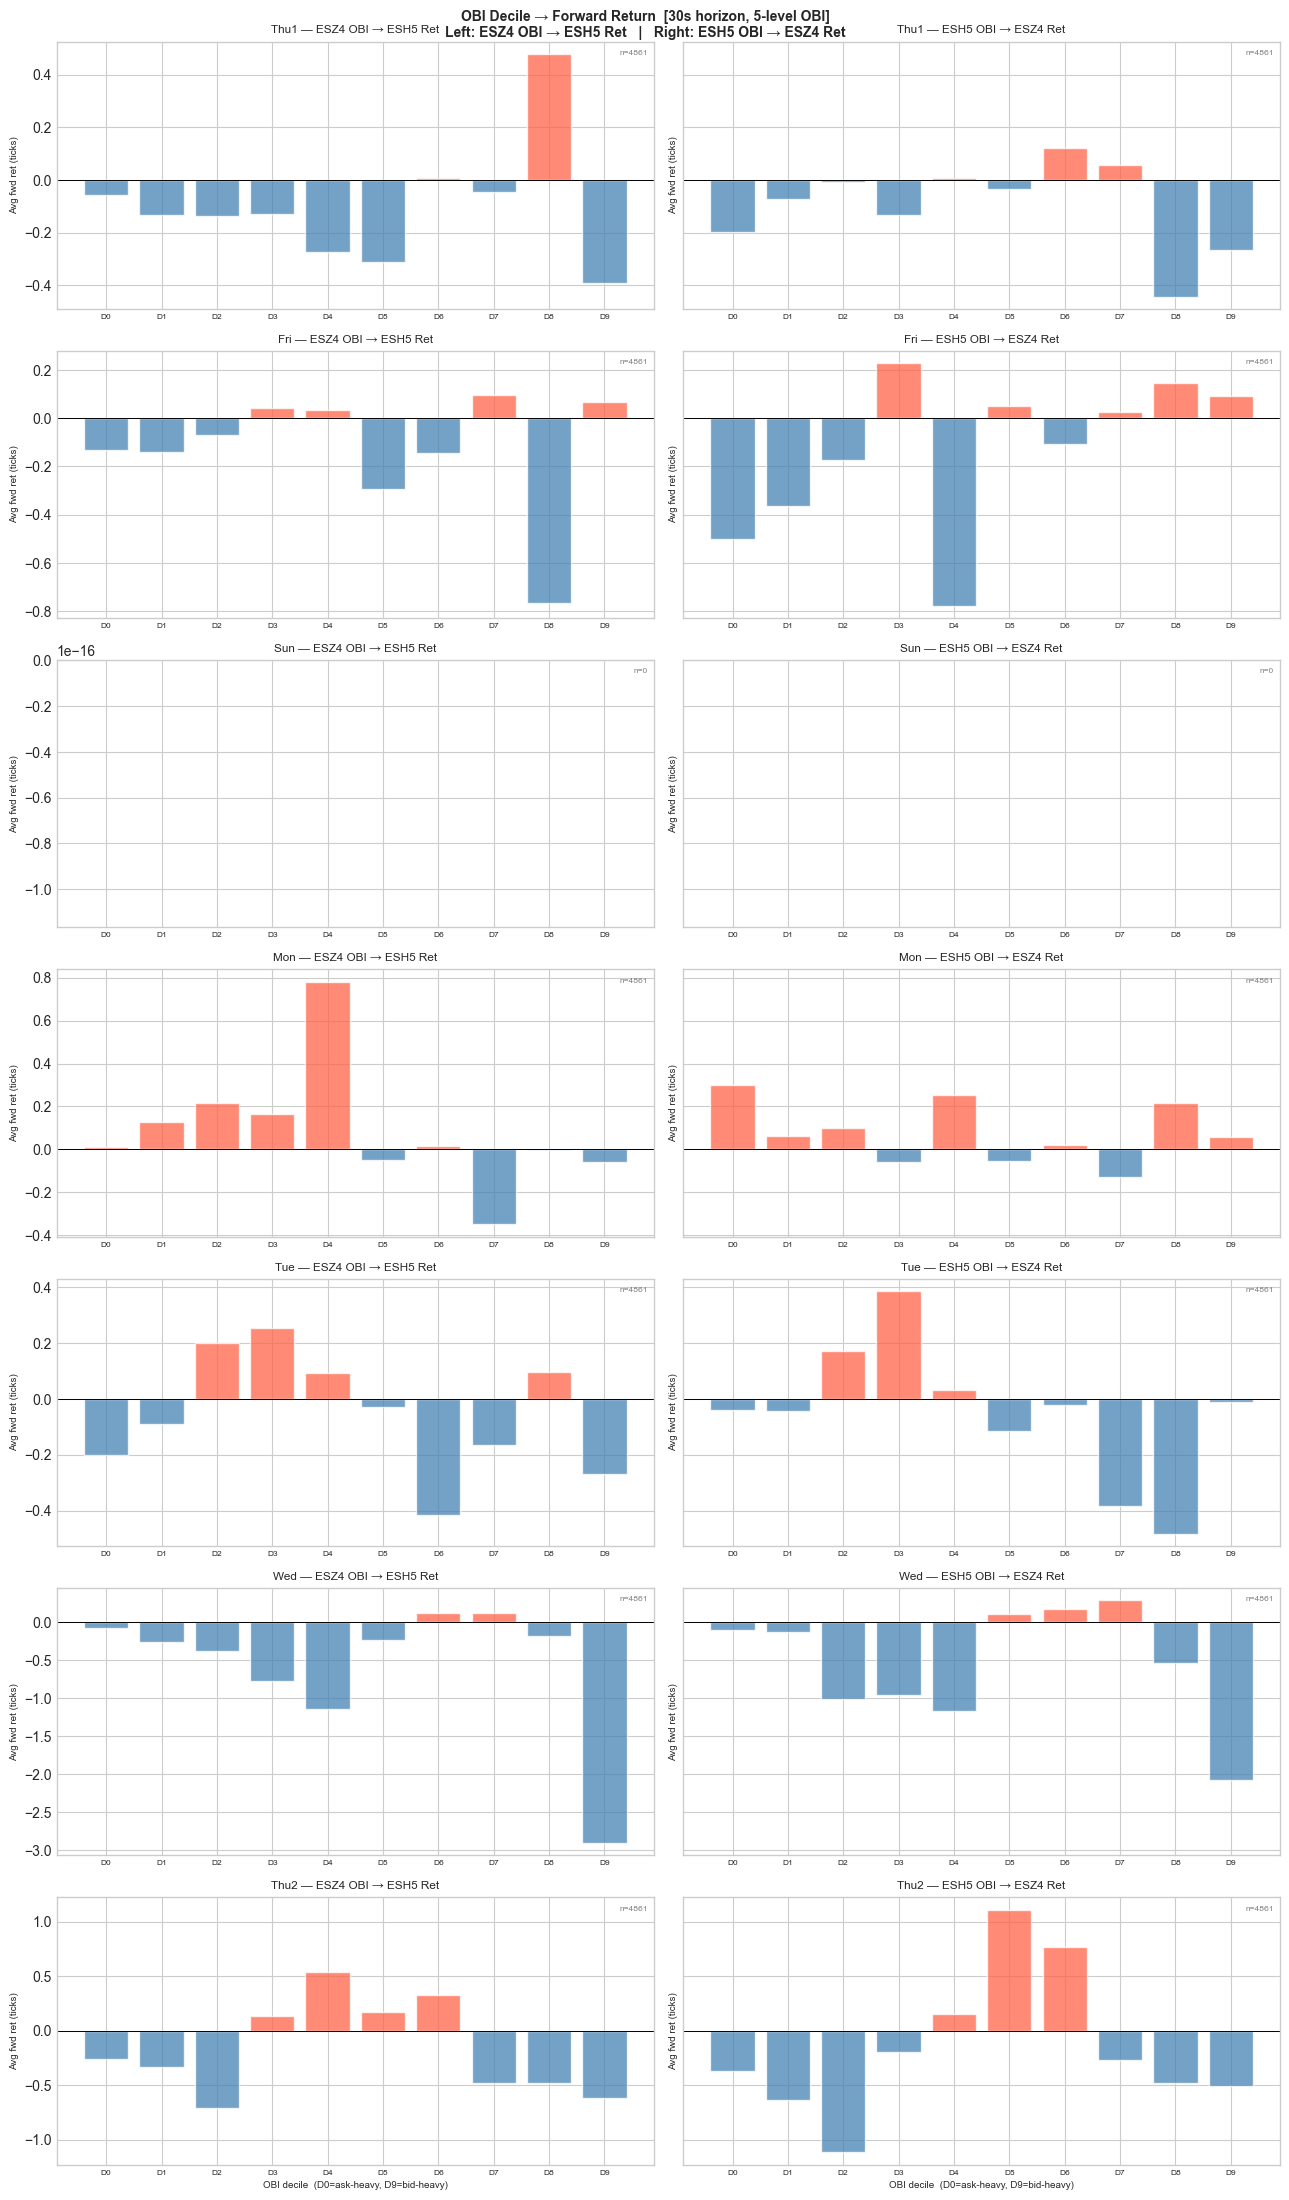

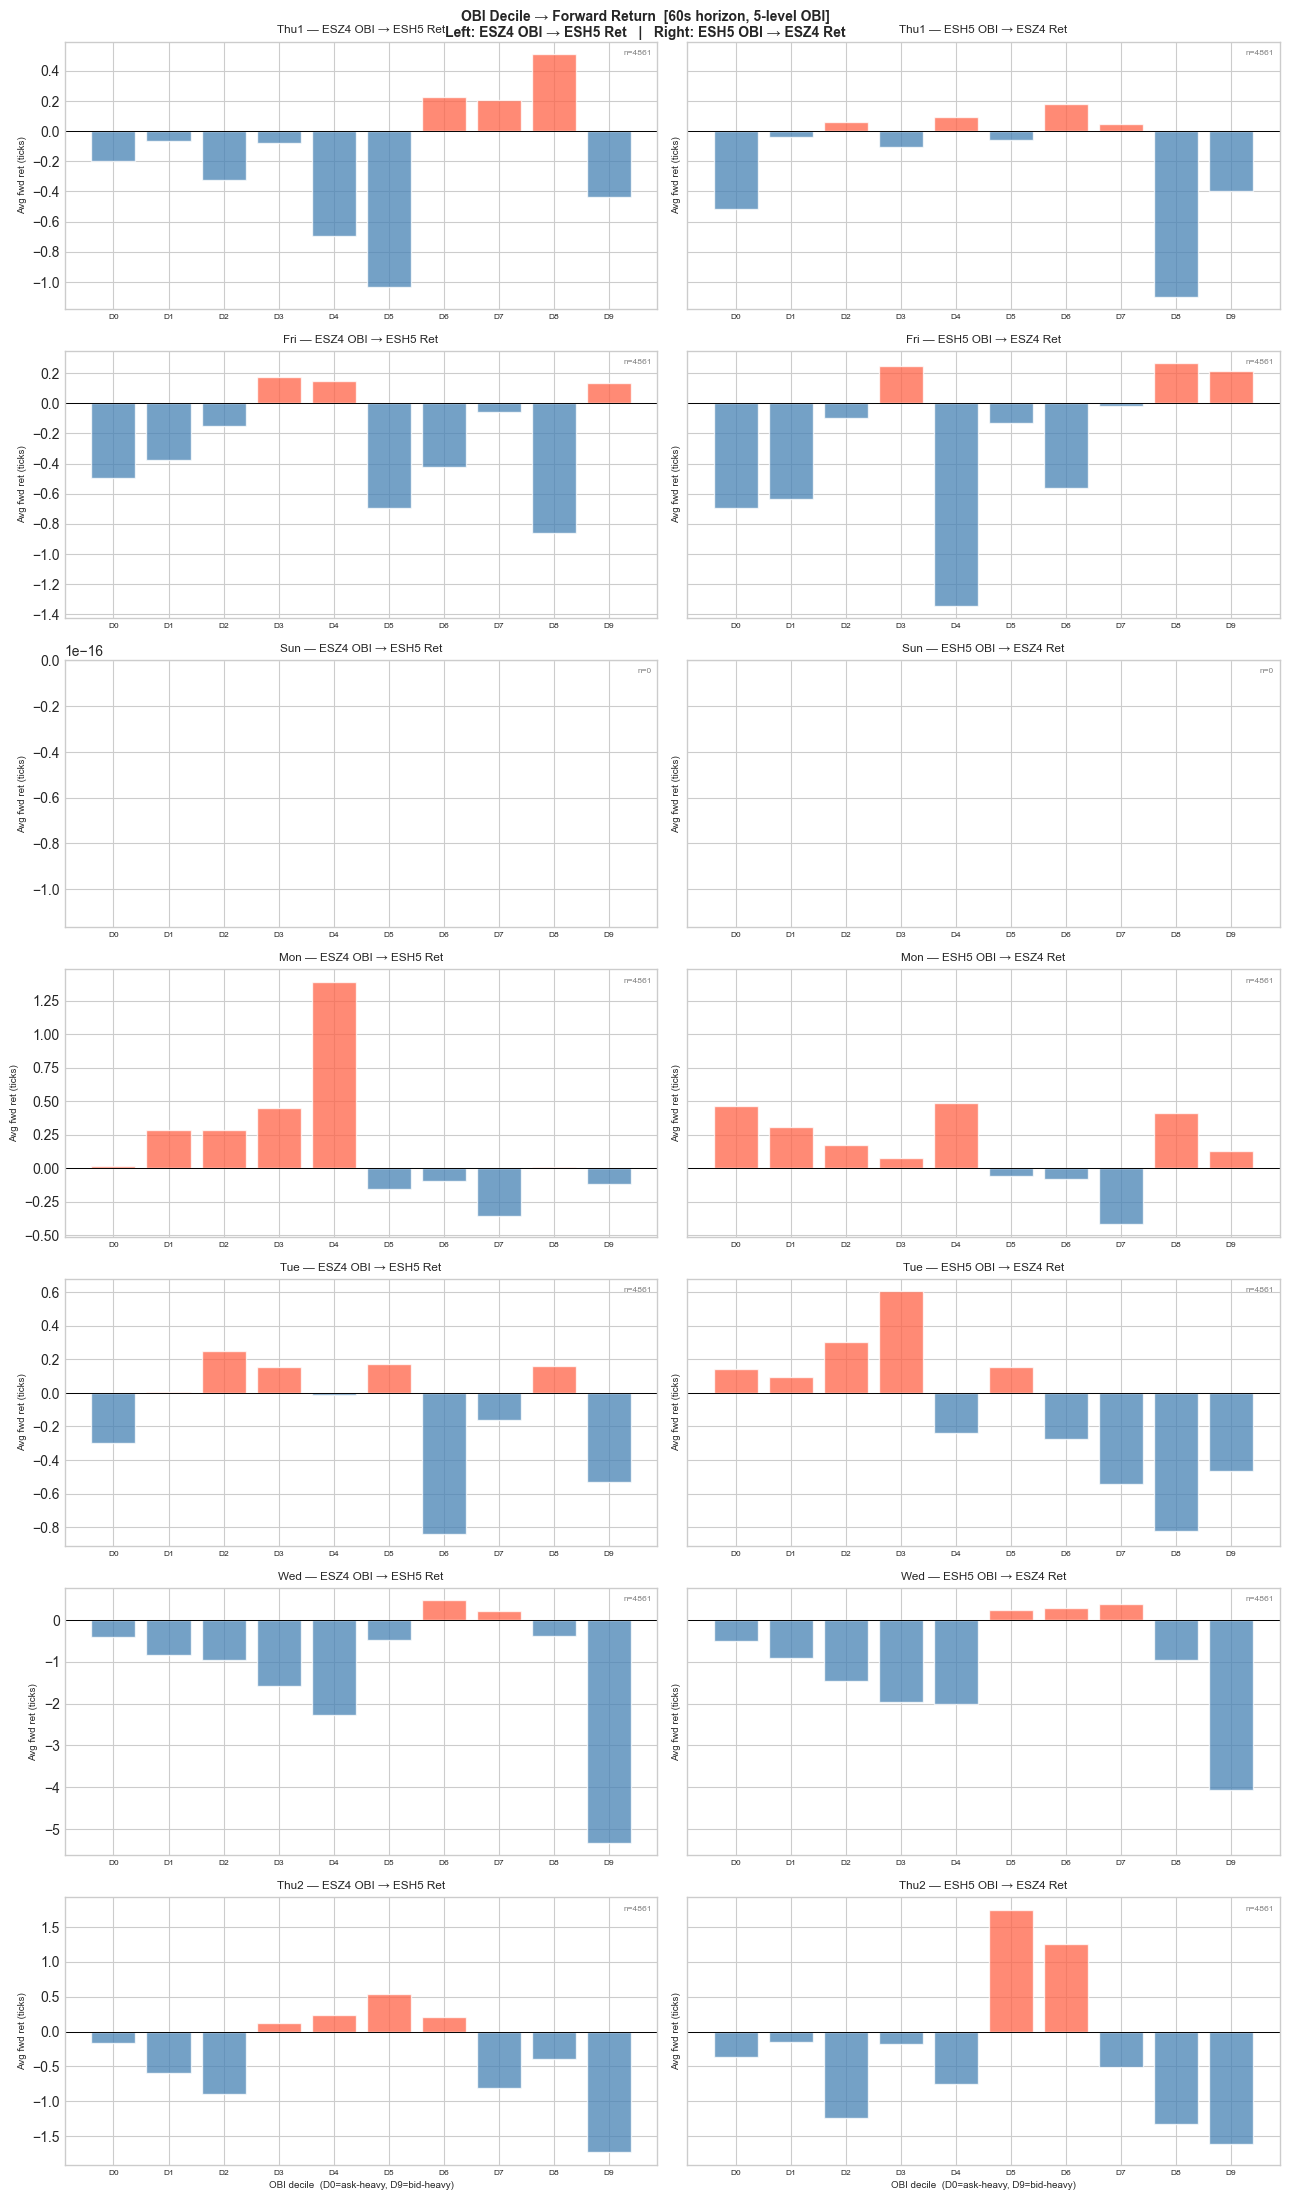

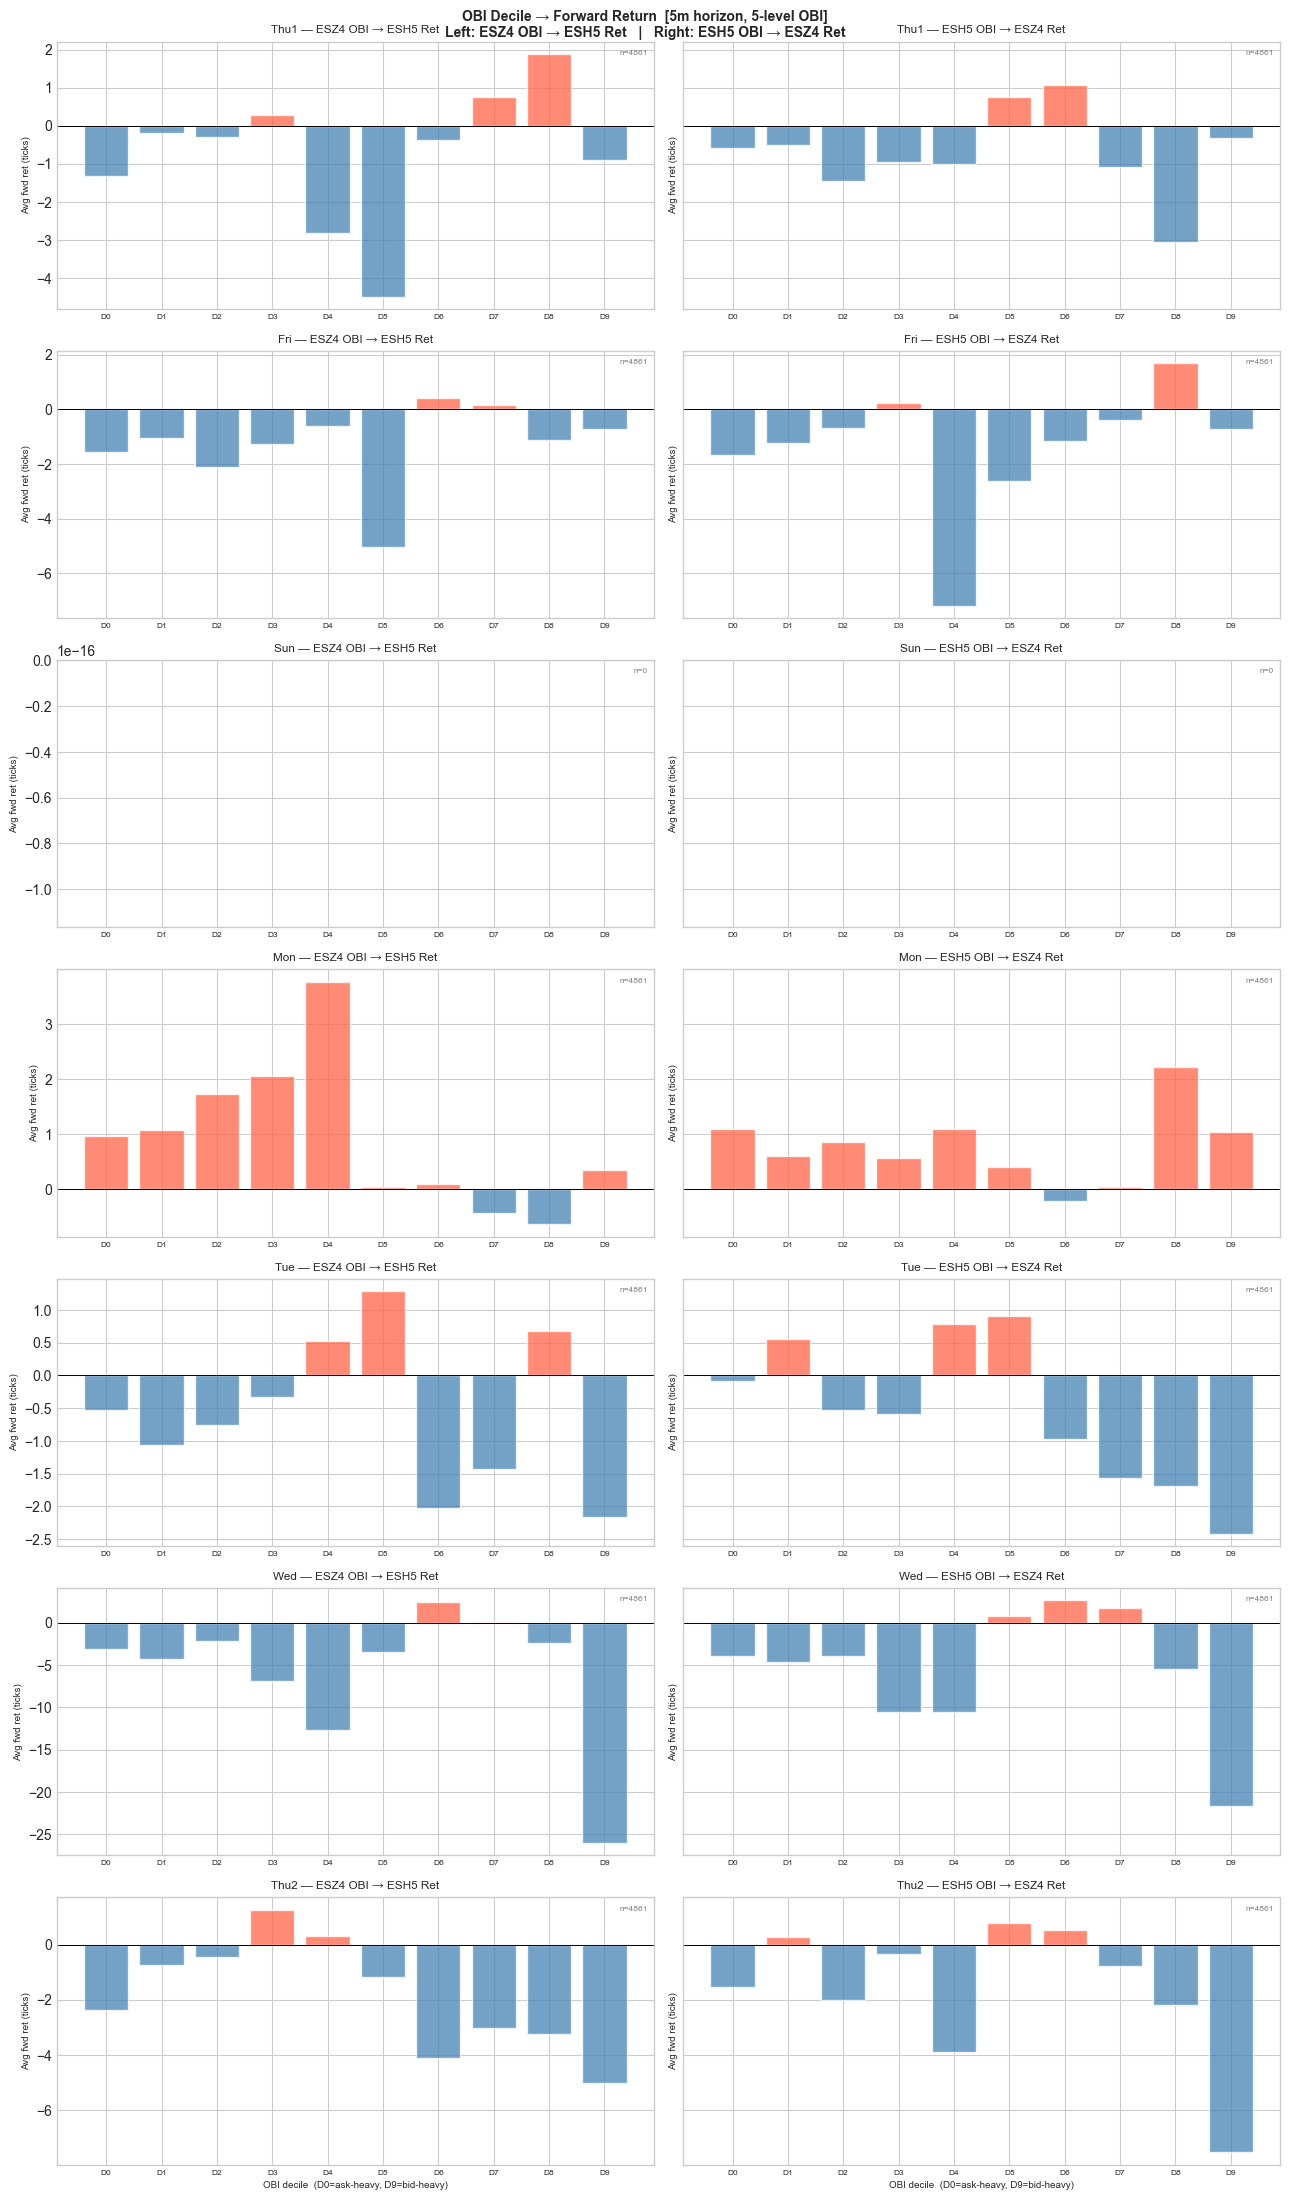

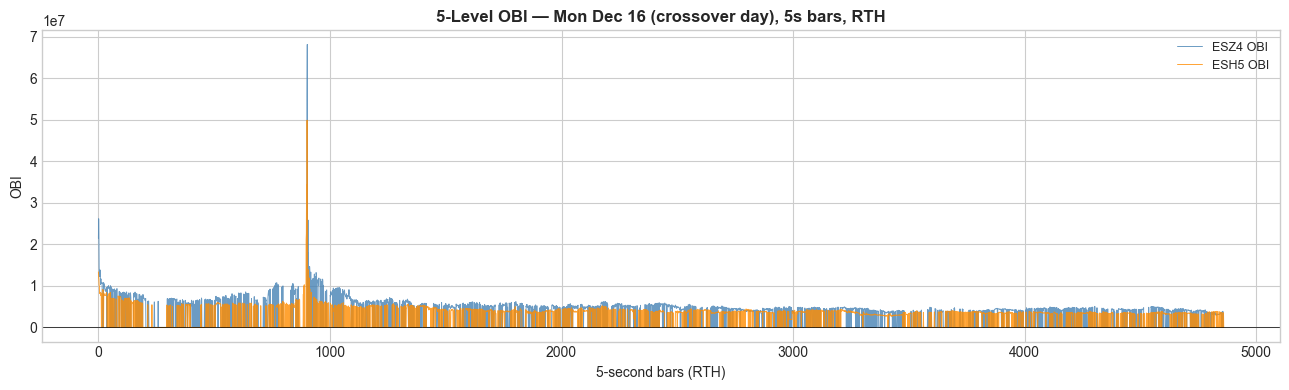

Pearson r (5s, all days):
  Front OBI → Back  Ret: -0.0063   (cross-market signal)
  Back  OBI → Front Ret: -0.0079   (cross-market signal)
  Front OBI → Front Ret: -0.0315   (own-market baseline)
  Back  OBI → Back  Ret: -0.0385   (own-market baseline)


In [26]:
OBI_COLS_ML = ['symbol',
               'bid_px_00', 'ask_px_00',
               'bid_sz_00', 'ask_sz_00',
               'bid_sz_01', 'ask_sz_01',
               'bid_sz_02', 'ask_sz_02',
               'bid_sz_03', 'ask_sz_03',
               'bid_sz_04', 'ask_sz_04']

HORIZONS = [('5s', 1), ('30s', 6), ('60s', 12), ('5m', 60)]

DAY_FILES = {
    '2024-12-12': 'Thu1',
    '2024-12-13': 'Fri',
    '2024-12-15': 'Sun',
    '2024-12-16': 'Mon',
    '2024-12-17': 'Tue',
    '2024-12-18': 'Wed',
    '2024-12-19': 'Thu2',
}

def load_obi_day(day_str: str, hz_bars: int = 1) -> pd.DataFrame:
    """
    Load one day's mbp10, compute 5-level OBI for each symbol,
    resample to 5s RTH bars, compute forward returns in ticks.
    Returns: front_obi, back_obi, front_dec, back_dec, front_ret, back_ret.
    """
    fpath = DATA_DIR / f'mbp10_{FRONT}_{BACK}_{ROLL_START}_{day_str}.parquet'
    df = pd.read_parquet(fpath, columns=OBI_COLS_ML)
    df['mid'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    bid_tot = sum(df[f'bid_sz_0{i}'] for i in range(5))
    ask_tot = sum(df[f'ask_sz_0{i}'] for i in range(5))
    df['obi'] = (bid_tot - ask_tot) / (bid_tot + ask_tot)

    obi5 = (
        df.groupby('symbol')[['mid', 'obi']]
        .resample('5s').last().ffill()
        .unstack('symbol')
        .between_time('13:30', '20:15')  # 08:30–15:15 EST; Dec is UTC−5
    )

    fwd_f = obi5[('mid', FRONT)].diff(hz_bars).shift(-hz_bars) / 0.25
    fwd_b = obi5[('mid', BACK )].diff(hz_bars).shift(-hz_bars) / 0.25
    fo = obi5[('obi', FRONT)]
    bo = obi5[('obi', BACK )]
    fo_dec = pd.qcut(fo, 10, labels=False, duplicates='drop')
    bo_dec = pd.qcut(bo, 10, labels=False, duplicates='drop')

    return pd.DataFrame({
        'front_obi': fo,     'back_obi':  bo,
        'front_dec': fo_dec, 'back_dec':  bo_dec,
        'front_ret': fwd_f,  'back_ret':  fwd_b,
    }).dropna(subset=['front_dec', 'back_dec'])


# ── Per-horizon × per-day × both-directions ───────────────────────────────────
_obi_cache: dict[int, dict[str, pd.DataFrame]] = {}

for hz_label, hz_bars in HORIZONS:
    if hz_bars not in _obi_cache:
        _obi_cache[hz_bars] = {}

    fig, axes = plt.subplots(len(DAY_FILES), 2,
                             figsize=(13, 3.2 * len(DAY_FILES)), sharey='row')
    fig.suptitle(
        f'OBI Decile → Forward Return  [{hz_label} horizon, 5-level OBI]\n'
        f'Left: {FRONT} OBI → {BACK} Ret   |   Right: {BACK} OBI → {FRONT} Ret',
        fontsize=10, fontweight='bold')

    for row, (day_str, day_label) in enumerate(DAY_FILES.items()):
        if day_str not in _obi_cache[hz_bars]:
            _obi_cache[hz_bars][day_str] = load_obi_day(day_str, hz_bars)
        day_df = _obi_cache[hz_bars][day_str]

        for col, (obi_dec, ret_col, direction) in enumerate([
            ('front_dec', 'back_ret',  f'{FRONT} OBI → {BACK} Ret'),
            ('back_dec',  'front_ret', f'{BACK} OBI → {FRONT} Ret'),
        ]):
            ax = axes[row, col]
            grp = day_df.groupby(obi_dec, observed=True)[ret_col].agg(['mean', 'count'])
            vals = grp['mean'].reindex(range(10)).fillna(0)
            ax.bar(vals.index, vals.values,
                   color=['tomato' if v > 0 else 'steelblue' for v in vals.values],
                   alpha=0.75, edgecolor='white', width=0.8)
            ax.axhline(0, color='black', lw=0.7)
            ax.set_title(f'{day_label} — {direction}', fontsize=8.5)
            ax.set_ylabel('Avg fwd ret (ticks)', fontsize=7)
            ax.set_xticks(range(10))
            ax.set_xticklabels([f'D{i}' for i in range(10)], fontsize=6)
            if row == len(DAY_FILES) - 1:
                ax.set_xlabel('OBI decile  (D0=ask-heavy, D9=bid-heavy)', fontsize=7)
            n_obs = int(day_df[obi_dec].notna().sum())
            ax.text(0.99, 0.97, f'n={n_obs}', transform=ax.transAxes,
                    fontsize=6, ha='right', va='top', color='gray')

    fig.tight_layout()
    plt.show()


# ── OBI time series — crossover day (Mon Dec 16) ──────────────────────────────
_d16 = _obi_cache.get(1, {}).get('2024-12-16')
if _d16 is None:
    _d16 = load_obi_day('2024-12-16', 1)

fig, ax = plt.subplots(figsize=(13, 4))
x16 = np.arange(len(_d16))
ax.plot(x16, _d16['front_obi'], color='steelblue',  lw=0.7, alpha=0.8, label=f'{FRONT} OBI')
ax.plot(x16, _d16['back_obi'],  color='darkorange', lw=0.7, alpha=0.8, label=f'{BACK} OBI')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('5-Level OBI — Mon Dec 16 (crossover day), 5s bars, RTH', fontweight='bold')
ax.set_ylabel('OBI')
ax.set_xlabel('5-second bars (RTH)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── Summary correlations (5s horizon, all days pooled) ────────────────────────
_cache1 = _obi_cache.get(1)
if _cache1 is not None:
    _all5 = pd.concat(list(_cache1.values()))
else:
    _all5 = pd.concat([load_obi_day(d, 1) for d in DAY_FILES])

r_f2b = _all5['front_obi'].corr(_all5['back_ret'])
r_b2f = _all5['back_obi' ].corr(_all5['front_ret'])
r_f2f = _all5['front_obi'].corr(_all5['front_ret'])
r_b2b = _all5['back_obi' ].corr(_all5['back_ret'])
print('Pearson r (5s, all days):')
print(f'  Front OBI → Back  Ret: {r_f2b:.4f}   (cross-market signal)')
print(f'  Back  OBI → Front Ret: {r_b2f:.4f}   (cross-market signal)')
print(f'  Front OBI → Front Ret: {r_f2f:.4f}   (own-market baseline)')
print(f'  Back  OBI → Back  Ret: {r_b2b:.4f}   (own-market baseline)')
corr_l1 = r_f2b

## 7. Trade Flow Imbalance (TFI)

**TFI** = (buy volume − sell volume) / total volume, per minute.  
Side='B' = buyer-initiated; side='A' = seller-initiated.  
Question: does front-month buy flow predict back-month midprice changes?

/var/folders/sr/p42wz5n11rzcm2dvgg2x75l00000gn/T/ipykernel_28536/2233601754.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  tfi_df = pd.concat([tfi_front, tfi_back, back_1m_ret.rename('back_ret_bps')], axis=1).dropna()


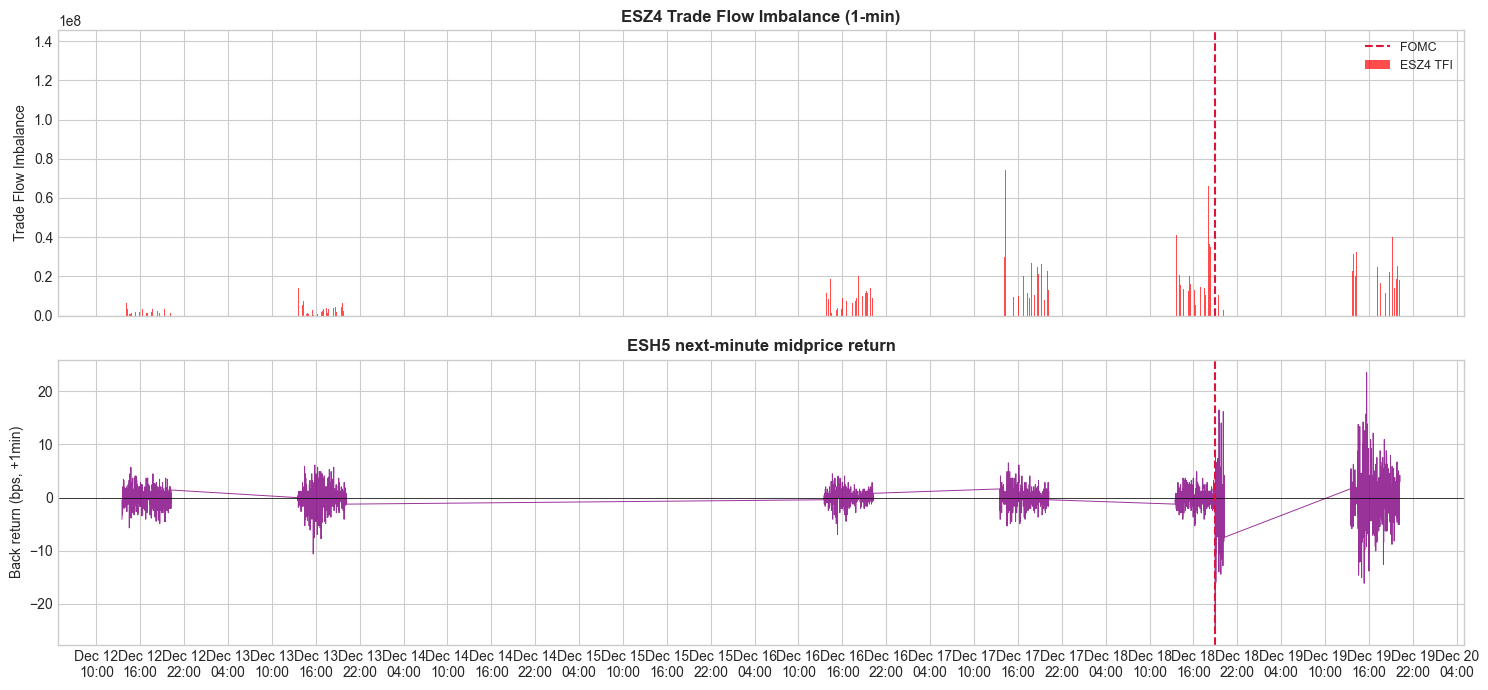

Front TFI → next-1min back return:  r = -0.0201
Back  TFI → next-1min back return:  r = -0.0012


In [27]:
trades = pd.read_parquet(DATA_DIR / f'trades_{FRONT}_{BACK}_{ROLL_START}.parquet')
trades_rth = trades.between_time('13:30', '20:15')  # 08:30–15:15 EST; Dec is UTC−5

def tfi_per_minute(df: pd.DataFrame, sym: str) -> pd.Series:
    s = df[df['symbol'] == sym].copy()
    s['signed_vol'] = s['size'] * s['side'].map({'B': 1, 'A': -1}).fillna(0)
    buy  = s[s['side'] == 'B']['size'].resample('1min').sum()
    sell = s[s['side'] == 'A']['size'].resample('1min').sum()
    total = (buy + sell).replace(0, np.nan)
    return ((buy - sell) / total).rename(f'tfi_{sym}')

tfi_front = tfi_per_minute(trades_rth, FRONT)
tfi_back  = tfi_per_minute(trades_rth, BACK)

# Back midprice change over next minute (from 1s resampled data)
back_1m = rth[('mid', BACK)].resample('1min').last().ffill()
back_1m_ret = back_1m.pct_change(1).shift(-1) * 1e4  # bps

tfi_df = pd.concat([tfi_front, tfi_back, back_1m_ret.rename('back_ret_bps')], axis=1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

ax = axes[0]
ax.bar(tfi_df.index, tfi_df[f'tfi_{FRONT}'],
       color=['red' if v > 0 else 'blue' for v in tfi_df[f'tfi_{FRONT}']],
       alpha=0.7, width=0.0005, label=f'{FRONT} TFI')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(FOMC_UTC, color='crimson', lw=1.5, linestyle='--', label='FOMC')
ax.set_ylabel('Trade Flow Imbalance')
ax.set_title(f'{FRONT} Trade Flow Imbalance (1-min)', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(tfi_df.index, tfi_df['back_ret_bps'], color='purple', lw=0.7, alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(FOMC_UTC, color='crimson', lw=1.5, linestyle='--')
ax.set_ylabel('Back return (bps, +1min)')
ax.set_title(f'{BACK} next-minute midprice return', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))

fig.tight_layout()
plt.show()

r_f2b = tfi_df[f'tfi_{FRONT}'].corr(tfi_df['back_ret_bps'])
r_b2b = tfi_df[f'tfi_{BACK}' ].corr(tfi_df['back_ret_bps'])
print(f'Front TFI → next-1min back return:  r = {r_f2b:.4f}')
print(f'Back  TFI → next-1min back return:  r = {r_b2b:.4f}')

## 8. FOMC Event Study — Dec 18 14:00 ET

Zoom into ±90 minutes around the FOMC announcement.  
Expected: spread compresses by ~3.5 pts as r_f steps from ~4.62% → ~4.37% (25bp cut).  
Watch: (a) speed of spread adjustment vs Sep's ~7pt step, (b) over/undershoot, (c) bid-ask widening.

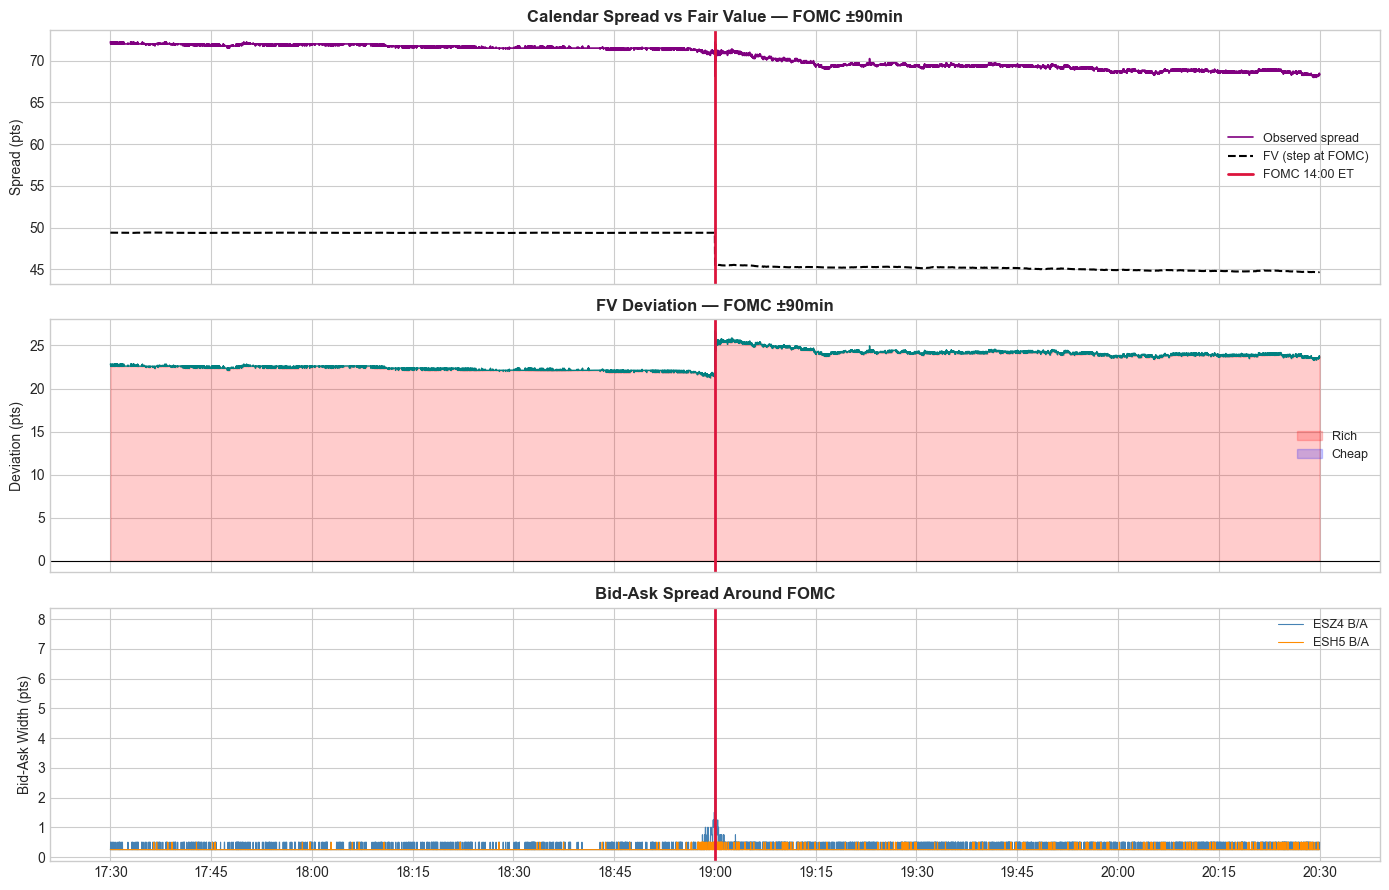

Mean spread pre-FOMC  : 71.706 pts
Mean spread post-FOMC : 69.301 pts
Empirical shift       : -2.404 pts
Model-predicted shift : -3.754 pts


In [28]:
FOMC_WINDOW = slice(FOMC_UTC - pd.Timedelta('90min'),
                    FOMC_UTC + pd.Timedelta('90min'))

fomc = rth.loc[FOMC_WINDOW].copy()
fomc['spread'] = fomc[('mid', BACK)] - fomc[('mid', FRONT)]

r_f_fomc = pd.Series(SOFR_PRE, index=fomc.index)
r_f_fomc[r_f_fomc.index >= FOMC_UTC] = SOFR_POST
fv_fomc  = fomc[('mid', FRONT)] * (r_f_fomc - DIV_YIELD) * dt_years
dev_fomc = fomc['spread'] - fv_fomc

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(fomc.index, fomc['spread'],   color='purple', lw=1.2, label='Observed spread')
ax.plot(fomc.index, fv_fomc,          color='black',  lw=1.5, linestyle='--', label='FV (step at FOMC)')
ax.axvline(FOMC_UTC, color='crimson', lw=2, label='FOMC 14:00 ET')
ax.set_ylabel('Spread (pts)')
ax.set_title('Calendar Spread vs Fair Value — FOMC ±90min', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(fomc.index, dev_fomc, color='teal', lw=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(FOMC_UTC, color='crimson', lw=2)
ax.fill_between(fomc.index, dev_fomc, 0, where=(dev_fomc > 0),
                alpha=0.2, color='red', label='Rich')
ax.fill_between(fomc.index, dev_fomc, 0, where=(dev_fomc < 0),
                alpha=0.2, color='blue', label='Cheap')
ax.set_ylabel('Deviation (pts)')
ax.set_title('FV Deviation — FOMC ±90min', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(fomc.index, fomc[('spread_1', FRONT)], color='steelblue',  lw=0.8, label=f'{FRONT} B/A')
ax.plot(fomc.index, fomc[('spread_1', BACK )], color='darkorange', lw=0.8, label=f'{BACK} B/A')
ax.axvline(FOMC_UTC, color='crimson', lw=2)
ax.set_ylabel('Bid-Ask Width (pts)')
ax.set_title('Bid-Ask Spread Around FOMC', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 15, 30, 45]))

fig.tight_layout()
plt.show()

pre  = fomc.loc[fomc.index < FOMC_UTC, 'spread'].mean()
post = fomc.loc[fomc.index > FOMC_UTC, 'spread'].mean()
print(f'Mean spread pre-FOMC  : {pre:.3f} pts')
print(f'Mean spread post-FOMC : {post:.3f} pts')
print(f'Empirical shift       : {post - pre:+.3f} pts')
print(f'Model-predicted shift : {fomc[("mid", FRONT)].mean() * (SOFR_POST - SOFR_PRE) * dt_years:+.3f} pts')

## 9. Intraday Spread Deviation — Distribution & Entry Opportunities

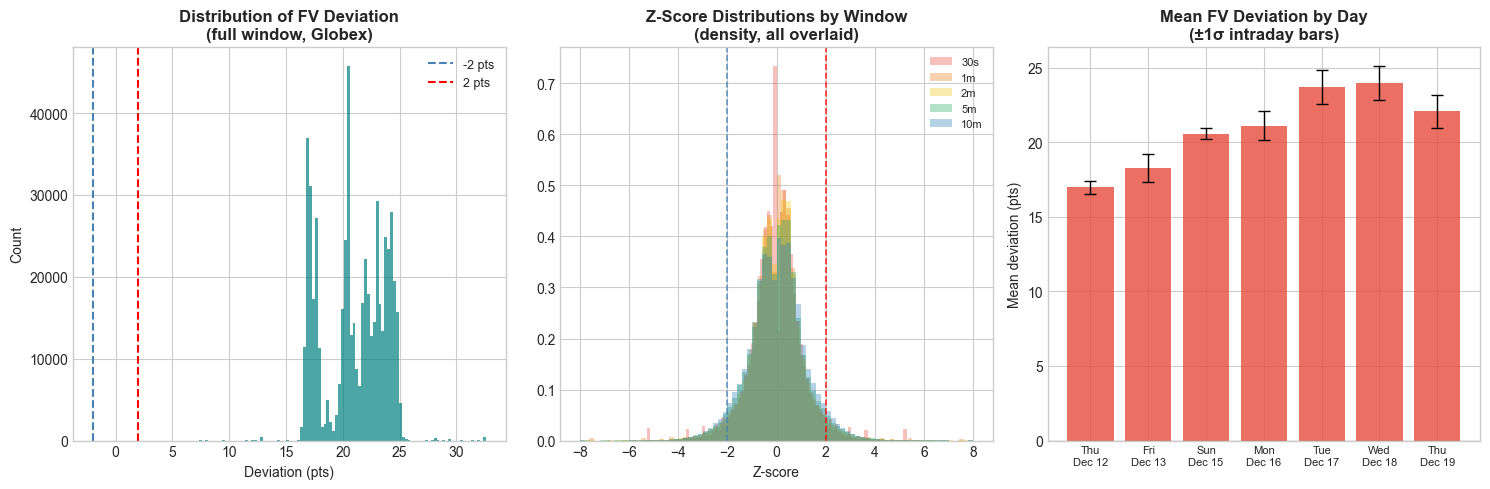

1m z-score: 19,132 long entries (3.76%),  18,018 short entries (3.54%)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution of raw deviation
ax = axes[0]
ax.hist(dev.dropna(), bins=100, color='teal', alpha=0.7, edgecolor='none')
for q, col in [(-2, 'steelblue'), (2, 'red')]:
    ax.axvline(q, color=col, lw=1.5, linestyle='--', label=f'{q} pts')
ax.set_xlabel('Deviation (pts)')
ax.set_ylabel('Count')
ax.set_title('Distribution of FV Deviation\n(full window, Globex)', fontweight='bold')
ax.legend(fontsize=9)

# Z-score distributions per window (overlaid)
ax = axes[1]
for _, wl in Z_WINDOWS:
    z = dev_z_all[wl].dropna()
    ax.hist(z.clip(-8, 8), bins=80, color=Z_COLORS[wl],
            alpha=0.35, edgecolor='none', label=wl, density=True)
for z, col in [(-2, 'steelblue'), (2, 'red')]:
    ax.axvline(z, color=col, lw=1.2, linestyle='--', alpha=0.8)
ax.set_xlabel('Z-score')
ax.set_title('Z-Score Distributions by Window\n(density, all overlaid)', fontweight='bold')
ax.legend(fontsize=8)

# Mean deviation by calendar day
ax = axes[2]
dev_by_day = dev.groupby(dev.index.normalize()).agg(['mean', 'std'])
days_label = [d.strftime('%a\n%b %d') for d in dev_by_day.index]
ax.bar(range(len(dev_by_day)), dev_by_day['mean'],
       yerr=dev_by_day['std'], capsize=4,
       color=['#e74c3c' if m >= 0 else '#3498db' for m in dev_by_day['mean']],
       alpha=0.8, error_kw={'linewidth': 1})
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(dev_by_day)))
ax.set_xticklabels(days_label, fontsize=8)
ax.set_ylabel('Mean deviation (pts)')
ax.set_title('Mean FV Deviation by Day\n(±1σ intraday bars)', fontweight='bold')

fig.tight_layout()
plt.show()

# Entry stats using default 1m window
n_long  = (dev_z < -2).sum()
n_short = (dev_z >  2).sum()
pct_l   = n_long  / len(dev_z.dropna()) * 100
pct_s   = n_short / len(dev_z.dropna()) * 100
print(f'1m z-score: {n_long:,} long entries ({pct_l:.2f}%),  {n_short:,} short entries ({pct_s:.2f}%)')


## 10. Alpha Signal Summary

In [30]:
summary = pd.DataFrame([
    {
        'Signal':      'FV Deviation Z-Score',
        'Type':        'Mean-reversion',
        'Input':       'mbp-10 midprice, SOFR, div yield',
        'Entry':       '|z| > 2σ (60s window)',
        'Exit':        '|z| < 0.5σ',
        'Note':        f'{pct_l+pct_s:.1f}% of RTH seconds at entry threshold',
    },
    {
        'Signal':      'Lead-Lag (front→back)',
        'Type':        'Momentum / price discovery',
        'Input':       'mbp-10 midprice 1s returns',
        'Entry':       f'Peak xcorr at lag={peak_lag}s (r={peak_corr:.3f})',
        'Exit':        'Mean reversion',
        'Note':        'Compare vs W1 lag=0s, r=0.849',
    },
    {
        'Signal':      'OBI (front L1)',
        'Type':        'Order flow',
        'Input':       'mbp-10 bid/ask sizes level 0',
        'Entry':       'Threshold on front OBI',
        'Exit':        '5s horizon, mean-revert',
        'Note':        f'Corr (front OBI→back ret): {corr_l1:.4f}   [W1: 0.0010]',
    },
    {
        'Signal':      'Trade Flow Imbalance',
        'Type':        'Order flow',
        'Input':       'trades schema, 1-min',
        'Entry':       'Large front buy/sell imbalance',
        'Exit':        '1-min horizon',
        'Note':        f'Corr (front TFI→back ret): {r_f2b:.4f}   [W1: 0.0049]',
    },
    {
        'Signal':      'FOMC / Event-Driven FV Jump',
        'Type':        'Structural / macro',
        'Input':       'FV model, rate calendar',
        'Entry':       'Rate decision + spread lag',
        'Exit':        'Spread catches FV step',
        'Note':        f'Dec 18: empirical shift {post-pre:+.2f} pts vs model {fomc[("mid",FRONT)].mean()*(SOFR_POST-SOFR_PRE)*dt_years:+.2f}   [W1: −0.78 vs −7.04]',
    },
]).set_index('Signal')

display(summary)

,Type,Input,Entry,Exit,Note
Signal,,,,,
FV Deviation Z-Score,Mean-reversion,"mbp-10 midprice, SOFR, div yield",|z| > 2σ (60s window),|z| < 0.5σ,7.3% of RTH seconds at entry threshold
Lead-Lag (front→back),Momentum / price discovery,mbp-10 midprice 1s returns,Peak xcorr at lag=0s (r=0.759),Mean reversion,"Compare vs W1 lag=0s, r=0.849"
OBI (front L1),Order flow,mbp-10 bid/ask sizes level 0,Threshold on front OBI,"5s horizon, mean-revert",Corr (front OBI→back ret): -0.0063 [W1: 0.0010]
Trade Flow Imbalance,Order flow,"trades schema, 1-min",Large front buy/sell imbalance,1-min horizon,Corr (front TFI→back ret): -0.0201 [W1: 0.0049]
FOMC / Event-Driven FV Jump,Structural / macro,"FV model, rate calendar",Rate decision + spread lag,Spread catches FV step,Dec 18: empirical shift -2.40 pts vs model -3....
